In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql


query = """SELECT
t.state_code AS State,
COUNT(*) AS State_Loans,
SUM(CASE WHEN t.agency = 'V' THEN 1 ELSE 0 END) AS VA_Loans,
SUM(CASE WHEN t.agency = 'V' THEN t2.unpaid_principal_balance ELSE 0 END) AS Total_VA_UPB,
ROUND(CAST(SUM(CASE WHEN t.agency = 'V' THEN 1 ELSE 0 END) AS FLOAT)/COUNT(*) * 100, 2) AS Percent_State_VA,
ROUND(CAST(SUM(CASE WHEN t.agency = 'V' THEN t2.unpaid_principal_balance ELSE 0 END) AS FLOAT)/SUM(t2.unpaid_principal_balance) * 100, 2) AS Percent_State_UPB_VA,
SUM(CASE WHEN t.agency = 'V' AND t2.months_delinquent <> 0 THEN 1 ELSE 0 END) AS Total_VA_Delinquencies
FROM
gnma_static_table t
LEFT JOIN mbs_loans_monthly t2 ON t2.disclosure_sequence_number = t.disclosure_sequence_number
GROUP BY t.state_code"""

df = read_sql(query)


print(df.head())

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_16920\1001302927.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  state  state_loans  va_loans  total_va_upb  percent_state_va  \
0    AK        38403     21508  5.879025e+09             56.01   
1    AL       279993     93492  1.892659e+10             33.39   
2    AR       154830     40986  7.052885e+09             26.47   
3    AZ       344066    126458  3.281724e+10             36.75   
4    CA       798834    265331  1.022632e+11             33.21   

   percent_state_upb_va  total_va_delinquencies  
0                 61.14                     642  
1                 42.13                    4549  
2                 33.56                    2188  
3                 41.69                    5002  
4                 39.54                   10193  


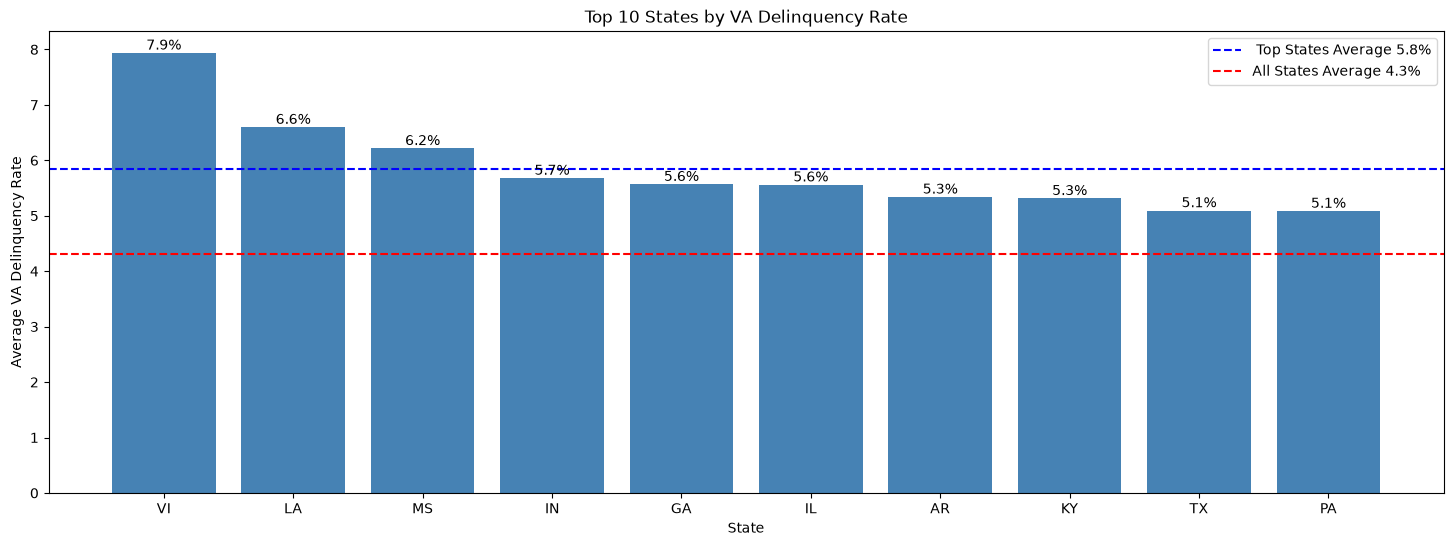

In [11]:
df['va_delinquency_rate'] = (df['total_va_delinquencies']/df['va_loans'])* 100

top_states = df.nlargest(10,'va_delinquency_rate')

plt.figure(figsize=(18,6))
bars = plt.bar(top_states['state'], top_states['va_delinquency_rate'], color='steelblue',)
plt.bar_label(bars,fmt='%.1f%%')
top_avg = top_states['va_delinquency_rate'].mean()
plt.axhline(top_avg, color='blue', linestyle='--', linewidth=1.5,label=f' Top States Average {top_avg:.1f}%')
avg = df['va_delinquency_rate'].mean()
plt.axhline(avg, color='red', linestyle='--', linewidth=1.5,label=f'All States Average {avg:.1f}%')
plt.title('Top 10 States by VA Delinquency Rate')
plt.xlabel('State')
plt.ylabel('Average VA Delinquency Rate')
plt.legend()